# 02 — ResNet50 + LSTM

In [1]:
import os, json, time, random, hashlib, warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import h5py
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from tqdm.auto import tqdm
from nltk.translate.bleu_score import corpus_bleu, SmoothingFunction

warnings.filterwarnings('ignore')

def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    if torch.cuda.is_available():
        torch.backends.cudnn.deterministic=True
        torch.backends.cudnn.benchmark=False

class CFG:
    SEED=42
    GUIDED_DIR=None
    PREP_DIR=None
    FEATURE_CACHE_DIR=None
    OLD_MODEL_PATH=None
    WARM_START_FROM_OLD_MODEL=True

    ENCODER='resnet50'
    ARCHITECTURE='Single-layer LSTM merge decoder'
    NUM_TAGS=6
    TAG_DIM=256

    BATCH_SIZE=128
    NUM_WORKERS=0
    BASE_LR=1e-4
    TAG_LR=3e-4
    WEIGHT_DECAY=1e-5
    GRAD_CLIP=5.0
    MAX_EPOCHS=30
    PATIENCE=6
    MIN_DELTA=0.0
    USE_TAG_BALANCED_SAMPLER=True
    N_COUNTERFACTUAL_IMAGES=5

    OUTPUT_DIR='/kaggle/working/guided_02_resnet50_lstm'
    BEST_CKPT='best_guided_checkpoint.pt'
    LAST_CKPT='last_guided_checkpoint.pt'
    FINAL_MODEL='guided_final_model.pt'

set_seed(CFG.SEED)
DEVICE=torch.device('cuda' if torch.cuda.is_available() else 'cpu')
os.makedirs(CFG.OUTPUT_DIR,exist_ok=True)
print('Device:',DEVICE)
print('Output:',CFG.OUTPUT_DIR)

Device: cuda
Output: /kaggle/working/guided_02_resnet50_lstm


## 1. پیدا کردن Dataset و preprocessing اصلی

In [2]:
GUIDED_REQUIRED={
    'guided_captions_physical_taxonomy.csv',
    'guided_token_ids_physical_taxonomy.npy',
    'tag_vocab_physical_taxonomy.json',
}
PREP_REQUIRED={'manifest.json','vocab.json','feature_index.json','captions.csv','features.h5'}

def find_dir(required, explicit=None):
    if explicit is not None:
        missing=[x for x in required if not os.path.isfile(os.path.join(explicit,x))]
        assert not missing, f'Missing from {explicit}: {missing}'
        return explicit
    candidates=[]
    for root in ['/kaggle/working','/kaggle/input']:
        if not os.path.exists(root): continue
        for d,_,files in os.walk(root):
            if required.issubset(set(files)): candidates.append(d)
    if not candidates: return None
    return sorted(set(candidates),key=lambda p:(0 if p.startswith('/kaggle/working') else 1,len(p),p))[0]

GUIDED_DIR=find_dir(GUIDED_REQUIRED,CFG.GUIDED_DIR)
PREP_DIR=find_dir(PREP_REQUIRED,CFG.PREP_DIR)
assert GUIDED_DIR is not None, 'Physical-Taxonomy guided dataset not found.'
assert PREP_DIR is not None, 'Notebook-01 preprocessing output not found.'
print('GUIDED_DIR:',GUIDED_DIR)
print('PREP_DIR:',PREP_DIR)

GUIDED_DIR: /kaggle/input/datasets/amirmrt04/tag-dataset/part3_guided_preprocessed_final
PREP_DIR: /kaggle/input/datasets/amirmrt04/dl-dataset/preprocessed


## 2. بارگذاری artifactها و بررسی سازگاری

In [3]:
with open(os.path.join(PREP_DIR,'manifest.json'),'r',encoding='utf-8') as f: prep_manifest=json.load(f)
with open(os.path.join(PREP_DIR,'vocab.json'),'r',encoding='utf-8') as f: vocab=json.load(f)
with open(os.path.join(PREP_DIR,'feature_index.json'),'r',encoding='utf-8') as f: feature_index=json.load(f)
with open(os.path.join(GUIDED_DIR,'tag_vocab_physical_taxonomy.json'),'r',encoding='utf-8') as f: tag_vocab=json.load(f)

guided_df=pd.read_csv(os.path.join(GUIDED_DIR,'guided_captions_physical_taxonomy.csv'))
GUIDED_TOKEN_PATH=os.path.join(GUIDED_DIR,'guided_token_ids_physical_taxonomy.npy')
guided_tokens=np.load(GUIDED_TOKEN_PATH,mmap_mode='r')

word2idx=vocab['word2idx']; idx2word=vocab['idx2word']
PAD_ID=int(vocab['special_tokens']['pad_id']); START_ID=int(vocab['special_tokens']['start_id'])
END_ID=int(vocab['special_tokens']['end_id']); UNK_ID=int(vocab['special_tokens']['unk_id'])
VOCAB_SIZE=len(idx2word); MAX_LEN=int(prep_manifest['text']['max_len'])
FEAT_DIM=int(feature_index['feature_dim']); NUM_IMAGE_TOKENS=int(feature_index['num_tokens'])
TAG_TO_ID={str(k):int(v) for k,v in tag_vocab['tag_to_id'].items()}
ID_TO_TAG={v:k for k,v in TAG_TO_ID.items()}; NUM_TAGS=len(TAG_TO_ID)

assert NUM_TAGS==6 and FEAT_DIM==2048 and NUM_IMAGE_TOKENS==49
assert guided_tokens.shape==(len(guided_df),MAX_LEN)
assert guided_df['guided_row_id'].astype(int).tolist()==list(range(len(guided_df)))
assert (guided_df['tag_id'].astype(int)==guided_df['tag'].map(TAG_TO_ID).astype(int)).all()

print('Rows:',len(guided_df),'Images:',guided_df.image.nunique(),'Vocab:',VOCAB_SIZE,'MAX_LEN:',MAX_LEN)
print('TAG_TO_ID:',TAG_TO_ID)
display(guided_df.groupby(['split','tag']).size().unstack(fill_value=0))

Rows: 45669 Images: 8090 Vocab: 2659 MAX_LEN: 20
TAG_TO_ID: {'<GENERAL>': 0, '<OBJECTS>': 1, '<ACTION>': 2, '<ENVIRONMENT>': 3, '<SHORT>': 4, '<DETAILED>': 5}


tag,<ACTION>,<DETAILED>,<ENVIRONMENT>,<GENERAL>,<OBJECTS>,<SHORT>
split,,,,,,
test,808,796,547,810,804,810
train,6440,6382,4318,6470,6444,6469
val,805,799,552,807,801,807


## 3. ResNet50 feature cache

In [4]:
FEATURES_H5_PATH=os.path.join(PREP_DIR,'features.h5')
assert os.path.isfile(FEATURES_H5_PATH)
with h5py.File(FEATURES_H5_PATH,'r') as h5: shape=tuple(h5['features'].shape)
assert shape[1:]==(49,2048)
print('Feature cache:',FEATURES_H5_PATH,shape)

Feature cache: /kaggle/input/datasets/amirmrt04/dl-dataset/preprocessed/features.h5 (8091, 49, 2048)


## 4. Dataset و DataLoader متوازن بر اساس Tag

In [5]:
class GuidedFeatureDataset(Dataset):
    def __init__(self,df,token_path,h5_path,split,global_pool=True):
        self.df=df[df['split']==split].copy().reset_index(drop=True)
        self.token_path=token_path; self.h5_path=h5_path; self.global_pool=bool(global_pool)
        self._tokens=None; self._h5=None
        self.row_ids=self.df['guided_row_id'].to_numpy(np.int64)
        self.feature_indices=self.df['feature_idx'].to_numpy(np.int64)
        self.tag_ids=self.df['tag_id'].to_numpy(np.int64)
    def __len__(self): return len(self.df)
    def _tok(self):
        if self._tokens is None: self._tokens=np.load(self.token_path,mmap_mode='r')
        return self._tokens
    def _fh5(self):
        if self._h5 is None: self._h5=h5py.File(self.h5_path,'r')
        return self._h5
    def __getitem__(self,i):
        tok=np.asarray(self._tok()[self.row_ids[i]],dtype=np.int64)
        spatial=np.asarray(self._fh5()['features'][int(self.feature_indices[i])],dtype=np.float32)
        feat=spatial.mean(0) if self.global_pool else spatial
        return torch.from_numpy(feat),torch.tensor(int(self.tag_ids[i]),dtype=torch.long),torch.from_numpy(tok)
    def __getstate__(self):
        s=self.__dict__.copy(); s['_tokens']=None; s['_h5']=None; return s

train_ds=GuidedFeatureDataset(guided_df,GUIDED_TOKEN_PATH,FEATURES_H5_PATH,'train')
val_ds=GuidedFeatureDataset(guided_df,GUIDED_TOKEN_PATH,FEATURES_H5_PATH,'val')
test_ds=GuidedFeatureDataset(guided_df,GUIDED_TOKEN_PATH,FEATURES_H5_PATH,'test')

def balanced_sampler(ds):
    ids=ds.df.tag_id.astype(int); counts=ids.value_counts().to_dict()
    weights=ids.map(lambda x:1.0/counts[int(x)]).to_numpy(np.float64)
    return WeightedRandomSampler(torch.as_tensor(weights,dtype=torch.double),len(weights),replacement=True,generator=torch.Generator().manual_seed(CFG.SEED))

train_loader=DataLoader(train_ds,batch_size=CFG.BATCH_SIZE,sampler=balanced_sampler(train_ds) if CFG.USE_TAG_BALANCED_SAMPLER else None,shuffle=not CFG.USE_TAG_BALANCED_SAMPLER,num_workers=0,pin_memory=DEVICE.type=='cuda')
val_loader=DataLoader(val_ds,batch_size=CFG.BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=DEVICE.type=='cuda')
test_loader=DataLoader(test_ds,batch_size=CFG.BATCH_SIZE,shuffle=False,num_workers=0,pin_memory=DEVICE.type=='cuda')
print('Train/Val/Test:',len(train_ds),len(val_ds),len(test_ds))
feat,tag,tok=next(iter(train_loader)); print('feature',feat.shape,'tag',tag.shape,'tokens',tok.shape)

Train/Val/Test: 36523 4571 4575
feature torch.Size([128, 2048]) tag torch.Size([128]) tokens torch.Size([128, 20])


## 5. مدل Tag-Controlled

In [6]:
class TaggedCaptionLSTM(nn.Module):
    def __init__(self,vocab_size,feat_dim=2048,embed_dim=256,hidden_dim=512,num_layers=1,dropout=0.5,pad_id=0,num_tags=6):
        super().__init__()
        self.image_proj=nn.Linear(feat_dim,embed_dim)
        self.embedding=nn.Embedding(vocab_size,embed_dim,padding_idx=pad_id)
        self.lstm=nn.LSTM(embed_dim*2,hidden_dim,num_layers=num_layers,batch_first=True,dropout=dropout if num_layers>1 else 0.0)
        self.dropout=nn.Dropout(dropout); self.fc=nn.Linear(hidden_dim,vocab_size)
        self.tag_embedding=nn.Embedding(num_tags,embed_dim)
        nn.init.zeros_(self.tag_embedding.weight)
    def condition(self,img_feat,tag_ids):
        return torch.tanh(self.image_proj(img_feat))+self.tag_embedding(tag_ids)
    def forward(self,img_feat,tag_ids,input_tokens):
        cond=self.condition(img_feat,tag_ids); word=self.embedding(input_tokens)
        cond=cond.unsqueeze(1).expand(-1,word.size(1),-1)
        out,_=self.lstm(torch.cat([word,cond],dim=-1))
        return self.fc(self.dropout(out))
    @torch.no_grad()
    def generate(self,img_feat,tag_ids,start_id,end_id,pad_id,max_new_tokens):
        self.eval(); b=img_feat.size(0); cond=self.condition(img_feat,tag_ids).unsqueeze(1)
        inp=torch.full((b,1),start_id,dtype=torch.long,device=img_feat.device); hidden=None
        gen=torch.full((b,max_new_tokens),pad_id,dtype=torch.long,device=img_feat.device)
        finished=torch.zeros(b,dtype=torch.bool,device=img_feat.device)
        for t in range(max_new_tokens):
            word=self.embedding(inp); out,hidden=self.lstm(torch.cat([word,cond],-1),hidden); logits=self.fc(out.squeeze(1))
            logits[:,pad_id]=-torch.inf; logits[:,start_id]=-torch.inf
            nxt=logits.argmax(-1); nxt=torch.where(finished,torch.full_like(nxt,pad_id),nxt); gen[:,t]=nxt
            finished=finished|nxt.eq(end_id); inp=torch.where(finished,torch.full_like(nxt,end_id),nxt).unsqueeze(1)
            if finished.all(): break
        return gen,finished

model=TaggedCaptionLSTM(VOCAB_SIZE,pad_id=PAD_ID,num_tags=NUM_TAGS).to(DEVICE)
print(model)

TaggedCaptionLSTM(
  (image_proj): Linear(in_features=2048, out_features=256, bias=True)
  (embedding): Embedding(2659, 256, padding_idx=0)
  (lstm): LSTM(512, 512, batch_first=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (fc): Linear(in_features=512, out_features=2659, bias=True)
  (tag_embedding): Embedding(6, 256)
)


## 6. Warm-start از مدل قبلی

In [7]:
EXPECTED_OLD_MODEL='baseline_lstm_final_model.pt'
OLD_HINT='part1_baseline_v2'

def safe_load(path):
    try: return torch.load(path,map_location=DEVICE,weights_only=False)
    except TypeError: return torch.load(path,map_location=DEVICE)

def find_old():
    if CFG.OLD_MODEL_PATH is not None:
        assert os.path.isfile(CFG.OLD_MODEL_PATH); return CFG.OLD_MODEL_PATH
    cand=[]
    for root in ['/kaggle/working','/kaggle/input']:
        if not os.path.exists(root): continue
        for d,_,files in os.walk(root):
            if EXPECTED_OLD_MODEL in files:
                cand.append(((0 if OLD_HINT in d else 1,0 if d.startswith('/kaggle/working') else 1,len(d)),os.path.join(d,EXPECTED_OLD_MODEL)))
    return sorted(cand,key=lambda x:x[0])[0][1] if cand else None

def extract_state(bundle):
    for key in ['decoder_state_dict','transformer_state_dict','model_state_dict']:
        if isinstance(bundle,dict) and isinstance(bundle.get(key),dict): return bundle[key],key
    if isinstance(bundle,dict) and bundle and all(torch.is_tensor(v) for v in bundle.values()): return bundle,'root'
    return None,None

OLD_MODEL_PATH=find_old(); warm_start_info=dict(requested=CFG.WARM_START_FROM_OLD_MODEL,path=OLD_MODEL_PATH,loaded=False)
if CFG.WARM_START_FROM_OLD_MODEL and OLD_MODEL_PATH:
    bundle=safe_load(OLD_MODEL_PATH); state,state_key=extract_state(bundle); assert state is not None
    missing,unexpected=model.load_state_dict(state,strict=False)
    assert set(missing)-{'tag_embedding.weight'}==set(), f'Unexpected missing: {missing}'
    assert not unexpected, f'Unexpected old keys: {unexpected}'
    warm_start_info.update(loaded=True,state_key=state_key,missing=list(missing)); print('Warm-start:',OLD_MODEL_PATH,'missing:',missing)
else:
    print('No previous model loaded. Expected:',EXPECTED_OLD_MODEL)

Warm-start: /kaggle/input/datasets/amirmrt04/cnn-lstm-output/part1_baseline_v2/baseline_lstm_final_model.pt missing: ['tag_embedding.weight']


## 7. Optimizer و Loss

In [8]:
criterion=nn.CrossEntropyLoss(ignore_index=PAD_ID)
tag_params=list(model.tag_embedding.parameters()); base_params=[p for n,p in model.named_parameters() if not n.startswith('tag_embedding.')]
optimizer=torch.optim.Adam([{'params':base_params,'lr':CFG.BASE_LR},{'params':tag_params,'lr':CFG.TAG_LR}],weight_decay=CFG.WEIGHT_DECAY)
AMP_ENABLED=DEVICE.type=='cuda'; scaler=torch.cuda.amp.GradScaler(enabled=AMP_ENABLED)

## 8. توابع Train / Validation

In [9]:
def move(batch):
    f,toktag,tok=batch
    return f.to(DEVICE,non_blocking=True),toktag.to(DEVICE,non_blocking=True),tok.to(DEVICE,non_blocking=True)

def train_epoch():
    model.train(); total=0.0; ntok=0
    for batch in tqdm(train_loader,desc='train',leave=False):
        feat,tag,tokens=move(batch); inp=tokens[:,:-1]; target=tokens[:,1:]; optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=AMP_ENABLED):
            logits=model(feat,tag,inp); loss=criterion(logits.reshape(-1,VOCAB_SIZE),target.reshape(-1))
        scaler.scale(loss).backward(); scaler.unscale_(optimizer); torch.nn.utils.clip_grad_norm_(model.parameters(),CFG.GRAD_CLIP)
        scaler.step(optimizer); scaler.update(); 
        n=int(target.ne(PAD_ID).sum()); total+=float(loss.item())*n; ntok+=n
    return total/max(ntok,1)

@torch.no_grad()
def eval_loss(loader):
    model.eval(); total=0.0; ntok=0
    for batch in loader:
        feat,tag,tokens=move(batch); inp=tokens[:,:-1]; target=tokens[:,1:]
        logits=model(feat,tag,inp); loss=criterion(logits.reshape(-1,VOCAB_SIZE),target.reshape(-1)); n=int(target.ne(PAD_ID).sum())
        total+=float(loss.item())*n; ntok+=n
    return total/max(ntok,1)

## 9. BLEU کلی و BLEU برای هر Tag

In [10]:
SMOOTH=SmoothingFunction().method1
def ids_to_words(ids):
    out=[]
    for i in ids:
        i=int(i)
        if i==END_ID: break
        if i in (PAD_ID,START_ID): continue
        if 0<=i<len(idx2word): out.append(idx2word[i])
    return out

def bleu_metrics(refs,hyps):
    if not refs: return dict(bleu1=float('nan'),bleu4=float('nan'))
    return dict(
        bleu1=float(corpus_bleu(refs,hyps,weights=(1,0,0,0),smoothing_function=SMOOTH)),
        bleu4=float(corpus_bleu(refs,hyps,weights=(.25,.25,.25,.25),smoothing_function=SMOOTH)),
    )

@torch.no_grad()
def evaluate_bleu(loader,ds,return_predictions=False):
    model.eval(); refs=[]; hyps=[]; rb=defaultdict(list); hb=defaultdict(list); rows=[]; offset=0
    for batch in tqdm(loader,desc='BLEU',leave=False):
        feat,tag,tokens=move(batch); generated,finished=model.generate(feat,tag,START_ID,END_ID,PAD_ID,MAX_LEN-1); generated=generated.cpu(); tcpu=tokens.cpu(); tagcpu=tag.cpu(); b=generated.size(0)
        for i in range(b):
            r=ids_to_words(tcpu[i].tolist()); h=ids_to_words(generated[i].tolist()); tid=int(tagcpu[i]); name=ID_TO_TAG[tid]
            refs.append([r]); hyps.append(h); rb[name].append([r]); hb[name].append(h)
            if return_predictions:
                row=ds.df.iloc[offset+i]
                rows.append(dict(image=row['image'],split=row['split'],tag=name,tag_id=tid,target_caption=row['target_caption'],generated_caption=' '.join(h),target_length=len(r),generated_length=len(h)))
        offset+=b
    per=[]
    for name in TAG_TO_ID:
        m=bleu_metrics(rb[name],hb[name]); per.append(dict(tag=name,n=len(rb[name]),**m))
    out=(bleu_metrics(refs,hyps),pd.DataFrame(per))
    if return_predictions: out=out+(pd.DataFrame(rows),)
    return out

## 10. آموزش و انتخاب بهترین مدل با Validation BLEU-4

In [11]:
BEST_PATH=os.path.join(CFG.OUTPUT_DIR,CFG.BEST_CKPT); LAST_PATH=os.path.join(CFG.OUTPUT_DIR,CFG.LAST_CKPT)
history=[]; best=-1.0; bad=0
for epoch in range(CFG.MAX_EPOCHS):
    t0=time.time(); tr=train_epoch(); vl=eval_loss(val_loader); vm,_=evaluate_bleu(val_loader,val_ds); b4=float(vm['bleu4'])
    row=dict(epoch=epoch+1,train_loss=tr,val_loss=vl,val_bleu1=vm['bleu1'],val_bleu4=b4,seconds=time.time()-t0); history.append(row)
    improved=b4>best+CFG.MIN_DELTA
    ckpt=dict(format_version=1,epoch=epoch,best_val_bleu4=b4 if improved else best,model_state_dict=model.state_dict(),optimizer_state_dict=optimizer.state_dict(),history=history,warm_start=warm_start_info,tag_to_id=TAG_TO_ID)
    torch.save(ckpt,LAST_PATH)
    if improved: best=b4; bad=0; torch.save(ckpt,BEST_PATH)
    else: bad+=1
    print(f"Epoch {{epoch+1:02d}} train={{tr:.4f}} val={{vl:.4f}} BLEU1={{vm['bleu1']:.4f}} BLEU4={{b4:.4f}}")
    if bad>=CFG.PATIENCE: print('Early stopping'); break
history_df=pd.DataFrame(history); history_df.to_csv(os.path.join(CFG.OUTPUT_DIR,'training_history.csv'),index=False); display(history_df)

train:   0%|          | 0/286 [00:00<?, ?it/s]

BLEU:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch {epoch+1:02d} train={tr:.4f} val={vl:.4f} BLEU1={vm['bleu1']:.4f} BLEU4={b4:.4f}


train:   0%|          | 0/286 [00:00<?, ?it/s]

BLEU:   0%|          | 0/36 [00:00<?, ?it/s]

...

Epoch {epoch+1:02d} train={tr:.4f} val={vl:.4f} BLEU1={vm['bleu1']:.4f} BLEU4={b4:.4f}


train:   0%|          | 0/286 [00:00<?, ?it/s]

BLEU:   0%|          | 0/36 [00:00<?, ?it/s]

Epoch {epoch+1:02d} train={tr:.4f} val={vl:.4f} BLEU1={vm['bleu1']:.4f} BLEU4={b4:.4f}
Early stopping


,epoch,train_loss,val_loss,val_bleu1,val_bleu4,seconds
0,1,2.213620,2.623249,0.293860,0.063872,79.641646
1,2,2.133710,2.593502,0.339758,0.084022,66.543832
2,3,2.091737,2.584884,0.354146,0.091428,65.911417
3,4,2.057864,2.578645,0.364433,0.093346,66.151724
4,5,2.036643,2.581591,0.356204,0.089258,66.793336
5,6,2.010629,2.577812,0.361894,0.091928,67.312945
6,7,1.991886,2.578825,0.364981,0.094209,66.965714
7,8,1.969468,2.589201,0.360366,0.091643,66.522495
8,9,1.954747,2.583504,0.364456,0.092641,66.567508
9,10,1.942922,2.594653,0.362739,0.092749,66.895487


## 11. منحنی‌های آموزش

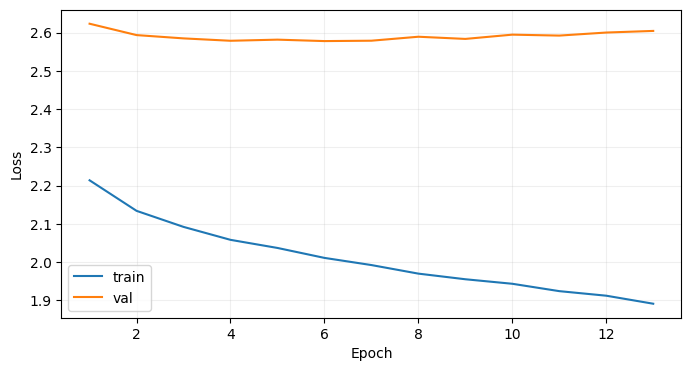

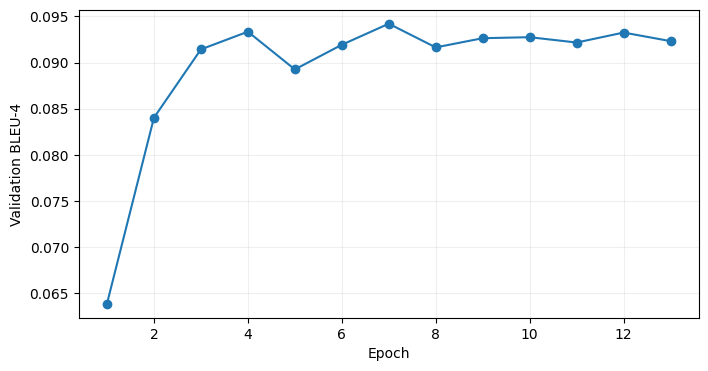

In [12]:
plt.figure(figsize=(8,4)); plt.plot(history_df.epoch,history_df.train_loss,label='train'); plt.plot(history_df.epoch,history_df.val_loss,label='val'); plt.xlabel('Epoch'); plt.ylabel('Loss'); plt.legend(); plt.grid(alpha=.2); plt.show()
plt.figure(figsize=(8,4)); plt.plot(history_df.epoch,history_df.val_bleu4,marker='o'); plt.xlabel('Epoch'); plt.ylabel('Validation BLEU-4'); plt.grid(alpha=.2); plt.show()

## 12. Test نهایی و معیارهای هر Tag

In [13]:
best_ckpt=safe_load(BEST_PATH); model.load_state_dict(best_ckpt['model_state_dict']); model.eval()
test_metrics,per_tag_metrics,test_predictions=evaluate_bleu(test_loader,test_ds,True)
print(json.dumps(test_metrics,indent=2)); display(per_tag_metrics)
per_tag_metrics.to_csv(os.path.join(CFG.OUTPUT_DIR,'per_tag_test_metrics.csv'),index=False)
test_predictions.to_csv(os.path.join(CFG.OUTPUT_DIR,'test_predictions.csv'),index=False)
with open(os.path.join(CFG.OUTPUT_DIR,'test_metrics.json'),'w') as f: json.dump(test_metrics,f,indent=2)
display(test_predictions.groupby('tag').agg(samples=('image','size'),target_mean_length=('target_length','mean'),generated_mean_length=('generated_length','mean')).round(3))

BLEU:   0%|          | 0/36 [00:00<?, ?it/s]

{
  "bleu1": 0.3661047501487122,
  "bleu4": 0.09676486471715884
}


,tag,n,bleu1,bleu4
0,<GENERAL>,810,0.336822,0.077385
1,<OBJECTS>,804,0.716405,0.430390
2,<ACTION>,808,0.318402,0.065051
3,<ENVIRONMENT>,547,0.357136,0.074997
4,<SHORT>,810,0.286755,0.047318
5,<DETAILED>,796,0.332090,0.075612


,samples,target_mean_length,generated_mean_length
tag,,,
<ACTION>,808,10.869,10.489
<DETAILED>,796,14.173,12.647
<ENVIRONMENT>,547,11.543,11.199
<GENERAL>,810,10.465,10.736
<OBJECTS>,804,4.192,4.276
<SHORT>,810,7.386,8.473


## 13. بررسی کنترل SHORT در برابر DETAILED

In [14]:
pivot=test_predictions.pivot_table(index='image',columns='tag',values='generated_length',aggfunc='first')
if '<SHORT>' in pivot.columns and '<DETAILED>' in pivot.columns:
    p=pivot[['<SHORT>','<DETAILED>']].dropna().copy(); p['diff']=p['<DETAILED>']-p['<SHORT>']
    display(p['diff'].describe().to_frame()); print('% detailed > short:',100*float((p['diff']>0).mean()))

,diff
count,796.000000
mean,4.158291
std,3.006503
min,-3.000000
25%,2.000000
50%,4.000000
75%,6.000000
max,14.000000


% detailed > short: 86.68341708542714


## 14. Same Image, Different Tags

In [15]:
@torch.no_grad()
def generate_for_row(row):
    with h5py.File(FEATURES_H5_PATH,'r') as h5: spatial=np.asarray(h5['features'][int(row.feature_idx)],dtype=np.float32)
    feat=torch.from_numpy(spatial.mean(0)).unsqueeze(0).to(DEVICE); tag=torch.tensor([int(row.tag_id)],device=DEVICE)
    gen,_=model.generate(feat,tag,START_ID,END_ID,PAD_ID,MAX_LEN-1); return ' '.join(ids_to_words(gen[0].cpu().tolist()))

counts=guided_df[guided_df.split=='test'].groupby('image').tag.nunique(); candidates=counts[counts>=5].index.tolist(); rng=random.Random(CFG.SEED)
selected=rng.sample(candidates,min(CFG.N_COUNTERFACTUAL_IMAGES,len(candidates))); rows=[]
for image in selected:
    g=guided_df[(guided_df.split=='test')&(guided_df.image==image)].sort_values('tag_id')
    for row in g.itertuples(): rows.append(dict(image=image,tag=row.tag,target=row.target_caption,generated=generate_for_row(row)))
counterfactual_df=pd.DataFrame(rows); display(counterfactual_df); counterfactual_df.to_csv(os.path.join(CFG.OUTPUT_DIR,'counterfactual_tag_examples.csv'),index=False)

,image,tag,target,generated
0,3655964639_21e76383d0.jpg,<GENERAL>,several people one being a woman in a black dr...,a man and woman are standing on a street
1,3655964639_21e76383d0.jpg,<OBJECTS>,a person and a dress and a bicycle,a person and a bicycle
2,3655964639_21e76383d0.jpg,<ACTION>,the woman wearing a red bow walks past a bicycle,a man and woman are standing on a street
3,3655964639_21e76383d0.jpg,<ENVIRONMENT>,woman in black dress with red accessories is w...,a man and a woman are standing on a street
4,3655964639_21e76383d0.jpg,<SHORT>,woman in a black dress walking on the street,a man and woman are standing on a street
5,3655964639_21e76383d0.jpg,<DETAILED>,a man chains his bike to a rack while a woman ...,a man and a woman are standing on a street wit...
6,2229179070_dc8ea8582e.jpg,<GENERAL>,a trainer runs next to his dog as it jumps thr...,a dog is jumping through a hoop
7,2229179070_dc8ea8582e.jpg,<OBJECTS>,a dog and a person,a dog and a person
8,2229179070_dc8ea8582e.jpg,<ACTION>,a dog is jumping through hoops held by people,a dog is jumping through a hoop
9,2229179070_dc8ea8582e.jpg,<SHORT>,a brown dog jumps through three hoops,a dog jumps through a hoop


## 15. ذخیره مدل نهایی

In [16]:
FINAL_PATH=os.path.join(CFG.OUTPUT_DIR,CFG.FINAL_MODEL)
bundle=dict(
    format_version=1,
    model_name='ResNet50 + Single-layer LSTM merge decoder + Tag Conditioning',
    source_implementation='02-part1-baseline-cnn-lstm',
    encoder='resnet50',
    tag_conditioning='additive tag embedding over image embedding',
    warm_start=warm_start_info,
    best_epoch=int(best_ckpt['epoch'])+1,
    best_validation_bleu4=float(best_ckpt['best_val_bleu4']),
    test_metrics=test_metrics,
    tag_to_id=TAG_TO_ID,
    decoder_state_dict={k:v.detach().cpu() for k,v in model.state_dict().items()},
    vocabulary=dict(word2idx=word2idx,idx2word=idx2word),
    generation_config=dict(start_id=START_ID,end_id=END_ID,pad_id=PAD_ID,unk_id=UNK_ID,max_new_tokens=MAX_LEN-1),
)
torch.save(bundle,FINAL_PATH); print('Saved:',FINAL_PATH)

Saved: /kaggle/working/guided_02_resnet50_lstm/guided_final_model.pt


## 16. فایل‌های خروجی

In [17]:
for p in sorted(Path(CFG.OUTPUT_DIR).glob('*')):
    if p.is_file(): print(f'{p.name:40s} {p.stat().st_size/1e6:8.2f} MB')

best_guided_checkpoint.pt                   56.08 MB
counterfactual_tag_examples.csv              0.00 MB
guided_final_model.pt                       18.79 MB
last_guided_checkpoint.pt                   56.08 MB
per_tag_test_metrics.csv                     0.00 MB
test_metrics.json                            0.00 MB
test_predictions.csv                         0.64 MB
training_history.csv                         0.00 MB
